(MovingBulk-ADR)=
# Moving Bulk ADR

WOur framework allows also to deal with moving boundaries. As an example, we start considering a bulk equation in the form

\begin{equation*}
\partial_t u + \nabla\cdot(\vec{B}u - d \nabla u) + cu = f \text{ on } \Omega(t)
\end{equation*}

The difference with respect to the [steady bulk case](Bulk-ADR) is that now the mesh is allowed to move in space.

It's weak formulation on a moving domain can be written, given a text function $v$, as

\begin{align*}
\frac{\mathrm{d}}{\mathrm{d} t}(u,v)_{\Omega(t)} + (d\nabla u, \nabla v)_{\Omega(t)} - (\vec{B} - \vec{w}, \nabla v)_{\Omega(t)} + (cu, v)_{\Omega(t)} = (f, v) + b.c.
\end{align*}

where $\vec{w}$ is the velocity of the mesh motion. Notably, we call $\vec{b}=\vec{B} - \vec{w}$ is now the **relative** velocity with respect to the mesh motion and that is the coefficient that is passed to the `ADRSolver`.

We need thus this case a parametrization that describe the position of our domain given the initial, reference one $\phi(\Omega(0), t) = \Omega(t)$, where
\begin{align*}
\vec{w}(\phi(\vec{x}, t)) = \frac{\partial}{\partial t}\phi(\vec{x}, t)
\end{align*}

We start by creating the mesh we will use.

In [1]:
from cosmos.utils.generate_surface_meshes import generate_circle
from ngsolve import *
from ngsolve.webgui import Draw
import pandas as pd
import matplotlib.pyplot as plt

mesh, _ = generate_circle()
Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

We choose now as simulation the class `MovingSimulation` of the `cosmos` package.

This class has to be initialized using the following arguments:
- the mesh
- the time variable `t` (as an `ngsolve` parameter)
- the timestep variable `dt` (as an `ngsolve` parameter)
- the final simulation time `T`

The `Moving` version of the simulation provides additional functionality to allow simple integration of mesh motion inside the simulation.

In [2]:
from cosmos.solvers.simulation import MovingSimulation

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = MovingSimulation(mesh=mesh, t=t, dt = dt, T = T)

The next step is the definition of the displacement. For this example we prescribe a general linear transformation $\phi(x) = A(t)*x+b(t)$ and compute some useful parameters that allow us to find the displacement.

In [3]:
A = CF(((1+0.25*sin(t))*cos(t), -sin(t),\
                sin(t), (1-0.25*sin(t))*cos(t)), dims = (2,2))
B = CF((0.2*t, 0.1*t))
phi = A*CF((x,y)) + B # Deformation map
detJ = Det(A)
invA = Cof(A).trans/detJ
inv_phi = invA*(CF((x,y)) - B) # Inverse of deformation map
w_phi = A.Diff(t)*inv_phi + B.Diff(t) # velocity of the moving domain
displ_ex = phi - CF((x,y))

Now we use the class `AddMotion` to tell the solver how to move the mesh.

In [4]:

simulation.AddMotion(function = displ_ex, domain = '.*', prescribed_everywhere = True)

It's time now to create and add the solver for our equation and we use the known  `ADRSolver` class of the `cosmos` package. Nothing changes here, but the user has to be aware that the motion is not buildt-in and the coefficients are thus the relative ones.

In [5]:
from cosmos.solvers.adr import ADRSolver
solver = ADRSolver(linear = True)
simulation.AddSolver(solver)

At this point we need to prescribe the coefficients of our solver. \
We create a manufactured solution so that later we can use it to perform convergence studies

In [6]:
from cosmos.solvers.tools import gradient

u_ex = cos(pi*x)*sin(pi*y)*cos(t)
d = 1 + x**2
c = 1 + x**2
b = CF((sin(x), 1))
flux = b*u_ex - d*gradient(u_ex, Id(2)) + w_phi*u_ex
rhs = (u_ex.Diff(t) + Trace(gradient(flux, Id(2))) + c*u_ex).Compile()
flux_c = b*u_ex
flux_d = - d*gradient(u_ex, Id(2))

solver.ComputeError(ex_sol = u_ex, norm = 'L2', folderpath = './adr_results/', filename = 'moving_bulk_adr_errors')

In the above:
- `flux_c` is the flux due to the advective term
- `flux_d` is the flux due to the diffusive term
This allows us to define various types of boundary conditions.

In particular we can prescribe:
- Dirichlet boundary conditions
- Neumann boundary conditions

The way the solver works is that this information is passed using dictionaries as follows

In [7]:
neu_b = {'.*': flux_c}
neu_d = {'.*': flux_d}
dir_d = {'.*': u_ex}
dir_b = {'.*': u_ex}

We then proceed to add the parameters to the solver. \
Subsequently we add the solver to the simulation. The simulation itself can contain multiple isolated solvers that share the time variables.



In [8]:
# # Using Dirichlet boundary conditions
# solver.AddSpecie(VorB = VOL,
#                 rhs = rhs,
#                 advection = b,
#                 diffusion = d,
#                 reaction = c,
#                 u0 = u_ex,
#                 dir_d = dir_d,
#                 dir_b = dir_b)

# Using Neumann boundary conditions
solver.AddSpecie(VorB = VOL,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                neu_b = neu_b,
                neu_d = neu_d)

We can finally run the simulation and plot the final result, comparing it with the exact solution. Remember that the mesh has moved so we need to also move it with the final displacement before plotting. This information is contained inside the simulation data at `simulation.data['dX']`

In [9]:
simulation.run()

print('Computed solution')
solver.draw_solution()
print('Exact solution')
mesh.SetDeformation(simulation.data['dX'])
Draw(u_ex, mesh)
mesh.UnsetDeformation()

Running Simulation...: 100%|███████████████| 10/10 [00:00<00:00, 59.12it/s]

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Additionally we can compute the error between the two solutions at every time-step. \
The software gives the option of computing either the $L^2$ or the $H^1$ norm between an exact solution and the discrete one

    Time   specie0
0    0.0  0.008566
1    0.1  0.020854
2    0.2  0.025568
3    0.3  0.026604
4    0.4  0.026102
5    0.5  0.024990
6    0.6  0.023810
7    0.7  0.022700
8    0.8  0.021527
9    0.9  0.020182
10   1.0  0.018725


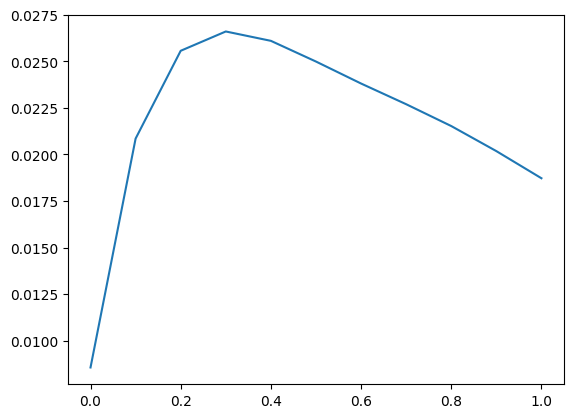

In [10]:
file_path = "./adr_results/moving_bulk_adr_errors"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

plt.plot(df['Time'], df['specie0'])

We can now also repeat the positivity preserving experiment explained in [the positivity preserving notebook](Positivity-ADR) and verify mass preservation

In [11]:
dt = Parameter(0.1)
T = 10
t = Parameter(0)

simulation_pp = MovingSimulation(mesh=mesh, t=t, dt = dt, T = T)

A = CF(((1+0.25*sin(t))*cos(t), -sin(t),\
                sin(t), (1-0.25*sin(t))*cos(t)), dims = (2,2))
B = CF((0.2*t, 0.1*t))
phi = A*CF((x,y)) + B # Deformation map
detJ = Det(A)
invA = Cof(A).trans/detJ
inv_phi = invA*(CF((x,y)) - B) # Inverse of deformation map
w_phi = A.Diff(t)*inv_phi + B.Diff(t) # velocity of the moving domain
displ_ex = phi - CF((x,y))

simulation_pp.AddMotion(function = displ_ex, domain = '.*', prescribed_everywhere = True)

solver_pp = ADRSolver(linear = True)
simulation_pp.AddSolver(solver_pp)

b_pp = CF((0.1,0))
d_pp = CF(0.0)
u0 = exp(-4*(x**2+y**2))
Draw(u0, mesh)
Fflux = CF((0,0))
Fneu_b = {'boundary': Fflux}
solver_pp.AddSpecie(VorB = VOL,
                advection = b_pp,
                diffusion = d_pp,
                u0 = u0,
                Fneu_b = Fneu_b,
                MP = True)

simulation_pp.run()

print('Computed solution')
solver_pp.draw_solution()

mass0 = Integrate(u0, mesh, order = 3)
mesh.SetDeformation(simulation_pp.data['dX'])
mass_end = Integrate(solver_pp.get_solution(), mesh, order = 3)
mesh.UnsetDeformation()

print('Relative mass error: ', (mass_end-mass0)/mass0)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Running Simulation...: 100%|█████████████| 100/100 [00:02<00:00, 43.82it/s]

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Relative mass error:  -9.559694054850602e-05
